# Healthcare Analytics: Doctor Visits Analysis
In this project, I am analyzing a healthcare dataset to understand why people go to the doctor.
I will look at how age, gender, income, illnesses, and insurance types affect the number of doctor visits.

First, let's import the necessary Python libraries for data analysis and charts.

In [ ]:
# Import libraries
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


##  Loading the Dataset


In [ ]:
import io
from google.colab import files
import pandas as pd

# Open file picker to select a file from your computer
uploaded = files.upload()

# Load the uploaded file (replace 'dataset.csv' with your file's name)
file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df.head()

Saving 1776250375-P2-Healthcare Analytics for Doctor Visits.csv to 1776250375-P2-Healthcare Analytics for Doctor Visits.csv


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


## Checking Data Structure and Missing Values

In [ ]:
# Check data types and null values
print("--- Missing Values in Each Column ---")
print(df.isnull().sum())

print("\n--- Column Data Types & Info ---")
df.info()

--- Missing Values in Each Column ---
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

--- Column Data Types & Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-

## Data Cleaning

In [ ]:
# Drop unwanted column and clean text
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    print("Dropped 'Unnamed: 0' index column.")

# Clean text columns to avoid spaces
text_cols = ["gender", "private", "freepoor", "freerepat", "nchronic", "lchronic"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print(f"Cleaned dataset shape: {df.shape}")
df.head()

Cleaned dataset shape: (5190, 12)


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


## Feature Engineering & Basic Statistics

In [ ]:
# Create simple helper columns
df["has_visited"] = np.where(df["visits"] > 0, 1, 0)

conditions = [
    (df["lchronic"] == "yes"),
    (df["nchronic"] == "yes") & (df["lchronic"] == "no"),
    (df["nchronic"] == "no") & (df["lchronic"] == "no"),
]
labels = ["Limiting Chronic", "Non-limiting Chronic", "No Chronic"]
df["chronic_type"] = np.select(conditions, labels, default="No Chronic")

# View statistics
print("--- Summary Statistics ---")
display(df.describe().round(2))

visit_pct = (df["has_visited"].mean()) * 100
print(f"\nPercentage of people who visited a doctor: {visit_pct:.2f}%")

--- Summary Statistics ---


,visits,age,income,illness,reduced,health,has_visited
count,5190.0,5190.00,5190.00,5190.00,5190.00,5190.00,5190.0
mean,0.3,0.41,0.58,1.43,0.86,1.22,0.2
std,0.8,0.20,0.37,1.38,2.89,2.12,0.4
min,0.0,0.19,0.00,0.00,0.00,0.00,0.0
25%,0.0,0.22,0.25,0.00,0.00,0.00,0.0
50%,0.0,0.32,0.55,1.00,0.00,0.00,0.0
75%,0.0,0.62,0.90,2.00,0.00,2.00,0.0
max,9.0,0.72,1.50,5.00,14.00,12.00,1.0



Percentage of people who visited a doctor: 20.21%


## Distribution of Doctor Visits

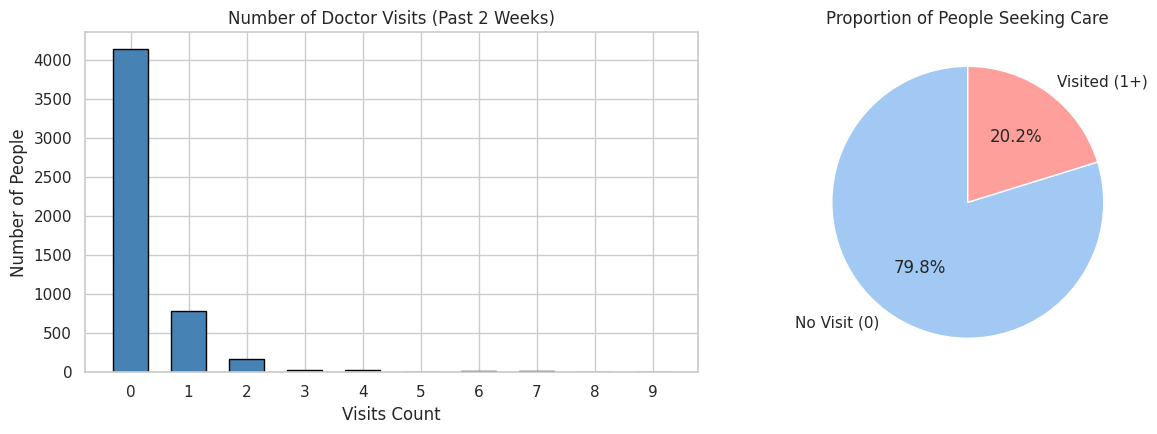

Visits frequency table:
visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64


In [ ]:
# Plot doctor visits distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Bar chart of visits count
visit_counts = df["visits"].value_counts().sort_index()
axes[0].bar(
    visit_counts.index,
    visit_counts.values,
    color="steelblue",
    edgecolor="black",
    width=0.6,
)
axes[0].set_title("Number of Doctor Visits (Past 2 Weeks)")
axes[0].set_xlabel("Visits Count")
axes[0].set_ylabel("Number of People")
axes[0].set_xticks(visit_counts.index)

# Visited vs Not Visited pie chart
status_counts = df["has_visited"].value_counts()
axes[1].pie(
    status_counts,
    labels=["No Visit (0)", "Visited (1+)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#a1c9f4", "#ff9f9b"],
)
axes[1].set_title("Proportion of People Seeking Care")

plt.tight_layout()
plt.show()

print("Visits frequency table:")
print(df["visits"].value_counts().sort_index())

## Gender and Age Analysis

--- Visits by Gender ---
        count   mean    std
gender                     
female   2702  0.362  0.858
male     2488  0.236  0.722


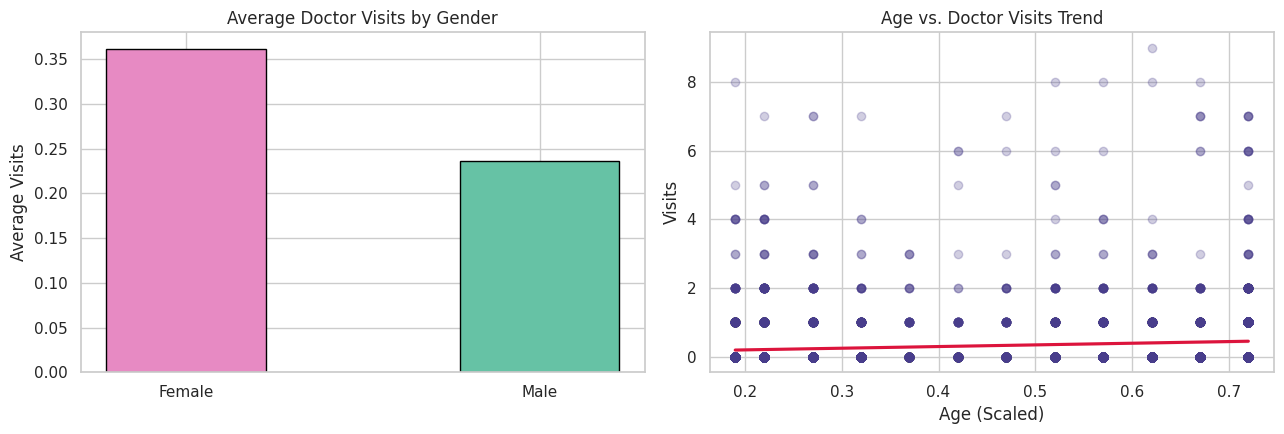

In [ ]:
# Gender and Age comparison
gender_summary = df.groupby("gender")["visits"].agg(["count", "mean", "std"])
print("--- Visits by Gender ---")
print(gender_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Gender bar chart
axes[0].bar(
    gender_summary.index.str.capitalize(),
    gender_summary["mean"],
    color=["#e78ac3", "#66c2a5"],
    edgecolor="black",
    width=0.45,
)
axes[0].set_title("Average Doctor Visits by Gender")
axes[0].set_ylabel("Average Visits")

# Age trend
sns.regplot(
    ax=axes[1],
    data=df,
    x="age",
    y="visits",
    scatter_kws={"alpha": 0.25, "color": "darkslateblue"},
    line_kws={"color": "crimson"},
)
axes[1].set_title("Age vs. Doctor Visits Trend")
axes[1].set_xlabel("Age (Scaled)")
axes[1].set_ylabel("Visits")

plt.tight_layout()
plt.show()

## Health Condition and Illness Impact

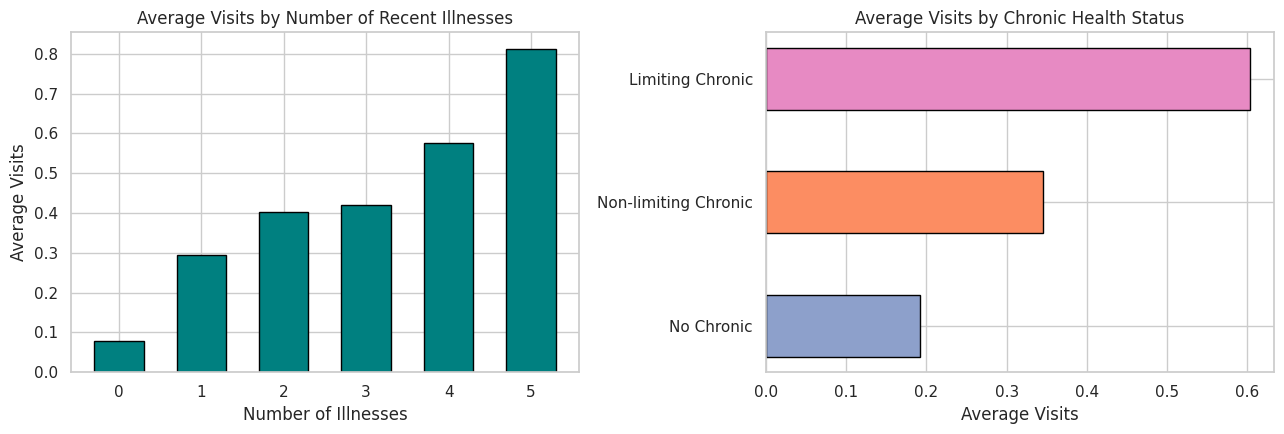

--- Chronic Status Group Summary ---
                      count   mean
chronic_type                      
Limiting Chronic        605  0.603
No Chronic             2493  0.192
Non-limiting Chronic   2092  0.346


In [ ]:
# Illness and Chronic illness impact
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Illness count vs average visits
illness_avg = df.groupby("illness")["visits"].mean()
axes[0].bar(
    illness_avg.index, illness_avg.values, color="teal", edgecolor="black", width=0.6
)
axes[0].set_title("Average Visits by Number of Recent Illnesses")
axes[0].set_xlabel("Number of Illnesses")
axes[0].set_ylabel("Average Visits")

# Chronic condition type vs average visits
chronic_avg = df.groupby("chronic_type")["visits"].mean().sort_values()
axes[1].barh(
    chronic_avg.index,
    chronic_avg.values,
    color=["#8da0cb", "#fc8d62", "#e78ac3"],
    edgecolor="black",
    height=0.5,
)
axes[1].set_title("Average Visits by Chronic Health Status")
axes[1].set_xlabel("Average Visits")

plt.tight_layout()
plt.show()

print("--- Chronic Status Group Summary ---")
print(df.groupby("chronic_type")["visits"].agg(["count", "mean"]).round(3))

## Insurance and Welfare Program Comparison

Average visits by insurance coverage:
                                no    yes
Private Insurance            0.307  0.295
Free Welfare (Poor)          0.308  0.158
Free Repatriation / Veteran  0.258  0.467


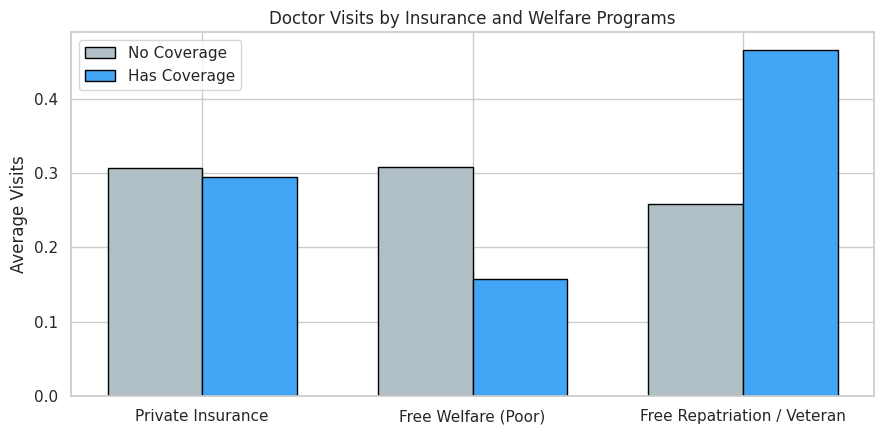

In [ ]:
# Compare insurance types
ins_data = pd.DataFrame(
    {
        "Private Insurance": df.groupby("private")["visits"].mean(),
        "Free Welfare (Poor)": df.groupby("freepoor")["visits"].mean(),
        "Free Repatriation / Veteran": df.groupby("freerepat")["visits"].mean(),
    }
).T

print("Average visits by insurance coverage:")
print(ins_data.round(3))

# Plot grouped bar chart
x = np.arange(len(ins_data))
width = 0.35

plt.figure(figsize=(9, 4.5))
plt.bar(
    x - width / 2,
    ins_data["no"],
    width,
    label="No Coverage",
    color="#b0bec5",
    edgecolor="black",
)
plt.bar(
    x + width / 2,
    ins_data["yes"],
    width,
    label="Has Coverage",
    color="#42a5f5",
    edgecolor="black",
)

plt.title("Doctor Visits by Insurance and Welfare Programs")
plt.xticks(x, ins_data.index)
plt.ylabel("Average Visits")
plt.legend()
plt.tight_layout()
plt.show()

## Correlation Heatmap Across Numerical Features

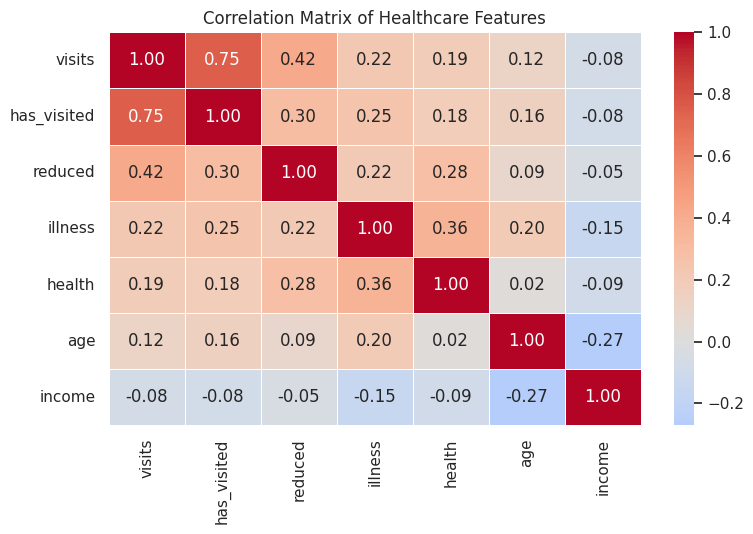


--- Correlation with Doctor Visits ---
visits         1.000
has_visited    0.751
reduced        0.419
illness        0.224
health         0.193
age            0.125
income        -0.077
Name: visits, dtype: float64


In [ ]:
# Correlation heatmap
numeric_cols = [
    "visits",
    "has_visited",
    "reduced",
    "illness",
    "health",
    "age",
    "income",
]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 5.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Correlation Matrix of Healthcare Features")
plt.tight_layout()
plt.show()

print("\n--- Correlation with Doctor Visits ---")
print(corr_matrix["visits"].sort_values(ascending=False).round(3))

## Project Summary and Key Findings

### Summary of Results:
- **Visit Frequency:** Out of 5,190 people, about 79.8% had zero doctor visits in the 2-week period. Only around 20.2% visited a doctor at least once.
- **Main Reasons for Visits:** The biggest factors linked to doctor visits are the number of days of reduced activity (reduced) and the count of recent illnesses (illness).
- **Chronic Illness Impact:** People with activity-limiting chronic conditions average about 0.60 visits, which is three times higher than people without any chronic conditions (0.19 visits).
- **Gender Differences:** Female patients visited doctors more often on average (0.36 visits) compared to male patients (0.24 visits).
- **Insurance and Subsidies:** People receiving free government repatriation or veteran benefits had higher visit rates, while having private insurance did not make a large difference in routine 2-week doctor visits.

### Conclusion:
Healthcare visits in this dataset are driven mostly by immediate health needs and severe chronic conditions rather than private insurance status alone. Clinics and hospitals can use these insights to better plan doctor availability and prioritize care for patients with chronic conditions.